In [1]:
import pandas as pd

from pathlib import Path

### Load Scores

In [2]:
exercise_path = Path("course_directory/ads_exercise")
output_path = Path("total_score")

In [3]:
scores = pd.read_csv(exercise_path.joinpath("grades.csv"))
scores.head()

,assignment,duedate,timestamp,student_id,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
0,04_python_basics_III,NaN,NaN,theresanadler,NaN,NaN,NaN,0.0,0.0,0.0,10.0
1,04_python_basics_III,NaN,NaN,moestenfau,NaN,NaN,NaN,0.0,0.0,0.0,10.0
2,04_python_basics_III,NaN,NaN,lucaabel,NaN,NaN,NaN,6.5,0.0,6.5,10.0
3,04_python_basics_III,NaN,NaN,moesten,NaN,NaN,NaN,0.0,0.0,0.0,10.0
4,04_python_basics_III,NaN,NaN,AhmedSofan10,NaN,NaN,NaN,8.0,0.0,8.0,10.0


In [4]:
score_long = scores.set_index(["student_id", "assignment"]).sort_index()
score_long

duedate  timestamp  last_name  first_name  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III      NaN        NaN        NaN         NaN   
             05_dicts_classes          NaN        NaN        NaN         NaN   
             06_numpy_scipy            NaN        NaN        NaN         NaN   
             07_pandas                 NaN        NaN        NaN         NaN   
             08_statistics             NaN        NaN        NaN         NaN   
...                                    ...        ...        ...         ...   
yp69ejot     07_pandas                 NaN        NaN        NaN         NaN   
             08_statistics             NaN        NaN        NaN         NaN   
             ads_assignment_1          NaN        NaN        NaN         NaN   
             ads_assignment_2          NaN        NaN        NaN         NaN   
             ads_assignment_3          NaN        NaN        NaN         NaN   

                                   email  raw_score  late_submission_penalty  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III    NaN        8.0                      0.0   
             05_dicts_classes        NaN       13.0                      0.0   
             06_numpy_scipy          NaN       10.0                      0.0   
             07_pandas               NaN        9.0                      0.0   
             08_statistics           NaN        0.0                      0.0   
...                                  ...        ...                      ...   
yp69ejot     07_pandas               NaN       12.0                      0.0   
             08_statistics           NaN        0.0                      0.0   
             ads_assignment_1        NaN        1.0                      0.0   
             ads_assignment_2        NaN        8.0                      0.0   
             ads_assignment_3        NaN       10.0                      0.0   

                                   score  max_score  
student_id   assignment                              
AhmedSofan10 04_python_basics_III    8.0       10.0  
             05_dicts_classes       13.0       13.0  
             06_numpy_scipy         10.0       10.0  
             07_pandas               9.0       12.0  
             08_statistics           0.0       11.0  
...                                  ...        ...  
yp69ejot     07_pandas              12.0       12.0  
             08_statistics           0.0       11.0  
             ads_assignment_1        1.0        1.0  
             ads_assignment_2        8.0        8.0  
             ads_assignment_3       10.0       10.0  

[512 rows x 9 columns]

In [5]:
sum_points = score_long["score"].unstack("assignment").sum(axis=1)
sum_points

student_id
AhmedSofan10    51.0
ArefehRh        48.0
Ashikluffy       1.0
Chamutalcast     9.0
Dan-github16     1.0
                ... 
viranya31        1.0
vv88alias       63.0
xindiyu         62.0
youssafB         0.0
yp69ejot        62.0
Length: 64, dtype: float64

In [8]:
max_score = score_long.xs(score_long.index[0][0], level="student_id")["max_score"].sum() # select the first student
max_score

75.0

In [10]:
# set this manually, when the score is not right
max_score = 64.0

In [11]:
percentage = (sum_points / max_score) * 100
percentage

student_id
AhmedSofan10    79.6875
ArefehRh        75.0000
Ashikluffy       1.5625
Chamutalcast    14.0625
Dan-github16     1.5625
                 ...   
viranya31        1.5625
vv88alias       98.4375
xindiyu         96.8750
youssafB         0.0000
yp69ejot        96.8750
Length: 64, dtype: float64

<Axes: >

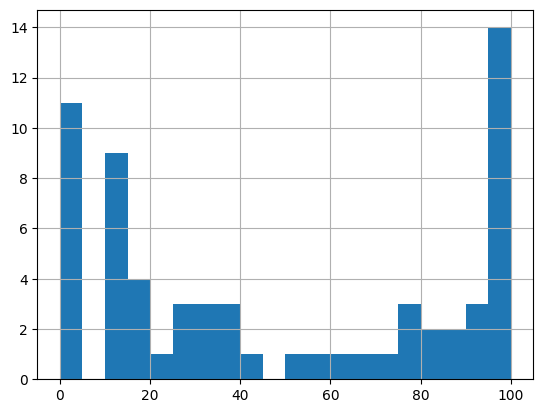

In [23]:
percentage.hist(bins=20)

In [65]:
import time

semester = "SoSe_23"

# export csv
timestr = time.strftime("%Y%m%d-%H%M%S")
percentage.to_csv(output_path.joinpath(semester+"-"+timestr+".csv"))